<a href="https://colab.research.google.com/github/sanmquin/AI/blob/main/research/2.Distance-Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Point-Cloud vs Description Distance Comparison

This notebook tests whether the **relative distances between channels in 20D embedding space** are
consistent with the **relative distances between their prose descriptions**.

The core question: if channel A's video embeddings are closest to channel B's, does the LLM
description of A also land closest to the description of B?

Three point-cloud distance metrics are computed and compared against one description-embedding
distance metric using Spearman rank correlation, Kendall τ, and top-k neighbourhood overlap.
Results are presented as tables and heatmaps.


## 1) Setup

Install dependencies and mount Drive.  `sentence-transformers` provides local description
embeddings without requiring an API key.


In [10]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn scipy sentence-transformers

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.spatial.distance import cdist, directed_hausdorff
from scipy.stats import spearmanr, kendalltau
from sklearn.preprocessing import normalize

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

try:
    from google.colab import drive
    drive.mount('/content/drive')
    is_colab = True
except ImportError:
    print('Not running in Colab — headless mode.')
    is_colab = False


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2) Load data

Load the 20D video embeddings and the `all_channels.json` artifact produced by
`1.Channel-Descriptions.ipynb`.  In headless mode, synthetic stand-ins are used for both.


In [11]:
DATA_PATH = Path(
    '/content/drive/MyDrive/Graphiko/exports/video_embeddings_reduced/latest/'
    'business_cluster_video_embeddings_reduced_20d.csv'
)
DESC_PATH = Path('/content/drive/MyDrive/Research/channel_descriptions/latest/all_channels.json')

if is_colab:
    RESEARCH_ROOT = Path('/content/drive/MyDrive/Research')
else:
    RESEARCH_ROOT = Path('./research_output')

# ---- Video embeddings ---------------------------------------------------
if not DATA_PATH.exists():
    print('Warning: embedding CSV not found — generating dummy data.')
    rng = np.random.default_rng(0)
    channel_names = [f'Channel_{c}' for c in ['Alpha', 'Beta', 'Gamma', 'Delta', 'Epsilon']]
    rows = []
    for i in range(200):
        ch = channel_names[i % len(channel_names)]
        rows.append({
            'video_id': f'vid_{i}', 'channel_id': f'ch_{i%5}', 'channel_name': ch,
            'video_title': f'Video {i}', 'view_count': int(rng.integers(1000, 100000)),
            **{f'embedding_reduced_{j+1:02d}': float(rng.standard_normal()) for j in range(20)},
        })
    df = pd.DataFrame(rows)
else:
    df = pd.read_csv(DATA_PATH)

channel_col = 'channel_name' if 'channel_name' in df.columns else 'channel_id'
dim_cols    = sorted([c for c in df.columns if c.startswith('embedding_reduced_')])
channels    = df[channel_col].dropna().unique().tolist()
print(f'Embeddings: {len(df):,} videos, {len(channels)} channels, {len(dim_cols)} dims.')

# ---- Channel descriptions -----------------------------------------------
if not DESC_PATH.exists():
    print('Warning: descriptions file not found — generating dummy descriptions.')
    descriptions = {
        ch: {'description': f'Dummy description for {ch}. This channel covers topics A, B and C.'}
        for ch in channels
    }
else:
    with open(DESC_PATH) as fh:
        all_desc = json.load(fh)
    descriptions = {ch: data for ch, data in all_desc.get('channels', {}).items()
                    if ch in channels}

# Align: use only channels present in both datasets
channels = [ch for ch in channels if ch in descriptions]
print(f'Aligned: {len(channels)} channels in both datasets.')


Embeddings: 1,344 videos, 27 channels, 20 dims.
Aligned: 27 channels in both datasets.


## 3) Point-cloud pairwise distances

Compute a symmetric N×N distance matrix between channels using three metrics:

- **Centroid distance** (`centroid`): Euclidean distance between per-channel means.  Fast and
  interpretable; treats each point cloud as a single representative point.
- **Hausdorff distance** (`hausdorff`): The maximum of the two directed Hausdorff distances.
  Sensitive to outlier videos that lie far from the opposing channel's cloud.
- **Mean minimum distance** (`mean_min`): For each video in channel A, find its nearest neighbour
  in channel B; average those distances (symmetrised).  Approximates how much the clouds interleave.

All three matrices are row-sum normalised after computation so values are comparable across
channels of different sizes.


In [12]:
def symmetric_mean_min(A: np.ndarray, B: np.ndarray) -> float:
    """Symmetrised mean-minimum distance: average of min-dist from A→B and B→A."""
    ab = cdist(A, B, metric='euclidean')
    return float(0.5 * (ab.min(axis=1).mean() + ab.min(axis=0).mean()))


def hausdorff_sym(A: np.ndarray, B: np.ndarray) -> float:
    """Symmetric Hausdorff distance (max of both directed Hausdorff distances)."""
    return float(max(directed_hausdorff(A, B)[0], directed_hausdorff(B, A)[0]))


n = len(channels)
# Pre-extract per-channel numpy arrays for reuse
clouds = {ch: df[df[channel_col] == ch][dim_cols].dropna().values for ch in channels}

centroid_mat  = np.zeros((n, n))
hausdorff_mat = np.zeros((n, n))
meanmin_mat   = np.zeros((n, n))

for i, ch_a in enumerate(channels):
    A = clouds[ch_a]
    for j, ch_b in enumerate(channels):
        if i == j:
            continue
        B = clouds[ch_b]
        centroid_mat[i, j]  = np.linalg.norm(A.mean(axis=0) - B.mean(axis=0))
        hausdorff_mat[i, j] = hausdorff_sym(A, B)
        meanmin_mat[i, j]   = symmetric_mean_min(A, B)

# Row-normalise (row sum = 1, diagonal = 0)
def row_normalise(M: np.ndarray) -> np.ndarray:
    row_sums = M.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    return M / row_sums

centroid_norm  = row_normalise(centroid_mat)
hausdorff_norm = row_normalise(hausdorff_mat)
meanmin_norm   = row_normalise(meanmin_mat)

print('Point-cloud distance matrices computed.')
print(f'  centroid  — range [{centroid_mat.min():.3f}, {centroid_mat.max():.3f}]')
print(f'  hausdorff — range [{hausdorff_mat.min():.3f}, {hausdorff_mat.max():.3f}]')
print(f'  mean_min  — range [{meanmin_mat.min():.3f}, {meanmin_mat.max():.3f}]')


Point-cloud distance matrices computed.
  centroid  — range [0.000, 0.386]
  hausdorff — range [0.000, 0.502]
  mean_min  — range [0.000, 0.387]


## 4) Description embedding distances

Embed each channel description with a local sentence-transformer model
(`all-MiniLM-L6-v2`).  This 384-dimensional model runs entirely on CPU without an API key.
Pairwise cosine distances are then computed and row-normalised in the same way as the
point-cloud matrices so the scales are comparable.


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize as sk_normalize

def make_embedder(texts_all: list):
    """
    Return an embedding function.  In Colab (or any environment with network access)
    a sentence-transformer is used for high-quality semantic embeddings.
    If the model cannot be downloaded (offline / CI), a TF-IDF fallback is used;
    the geometry is cruder but the notebook still runs end-to-end.
    """
    try:
        from sentence_transformers import SentenceTransformer as _ST
        _model = _ST('all-MiniLM-L6-v2')
        print('  Using sentence-transformer embeddings.')
        def _encode(texts):
            return _model.encode(texts, convert_to_numpy=True, show_progress_bar=False)
        return _encode
    except Exception as load_exc:
        print(f'  sentence-transformers unavailable ({load_exc}); falling back to TF-IDF.')
        _tfidf = TfidfVectorizer(max_features=512, ngram_range=(1, 2))
        _tfidf.fit(texts_all)
        def _encode(texts):
            arr = _tfidf.transform(texts).toarray()
            return sk_normalize(arr, norm='l2')
        return _encode

print('Preparing description embeddings…')
all_texts = [descriptions[ch]['description'] for ch in channels]
encode_fn  = make_embedder(all_texts)
desc_texts = [descriptions[ch]['description'] for ch in channels]
desc_embs  = encode_fn(desc_texts)

# Cosine distance matrix
desc_cos = cdist(desc_embs, desc_embs, metric='cosine')
np.fill_diagonal(desc_cos, 0.0)
desc_cos_norm = row_normalise(desc_cos)

print(f'Description embeddings shape: {desc_embs.shape}')
print(f'Cosine distance range: [{desc_cos.min():.4f}, {desc_cos.max():.4f}]')


Preparing description embeddings…


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Using sentence-transformer embeddings.
Description embeddings shape: (27, 384)
Cosine distance range: [0.0000, 0.7484]


## 5) Rank agreement between point-cloud and description distances

For each pair of distance representations (point-cloud metric vs description cosine), compute:

- **Spearman ρ**: rank correlation of all off-diagonal pairwise distances.  Measures whether
  pairs that are close in one space are also close in the other.
- **Kendall τ**: a stricter concordance measure that counts concordant vs discordant pairs.
- **Top-3 neighbour overlap**: for each channel, what fraction of its 3 nearest neighbours
  agree between the two representations?  Values range from 0 (no overlap) to 1 (perfect match).

Positive Spearman ρ means the two representations agree on which channels are similar.


In [14]:
def extract_offdiag(M: np.ndarray) -> np.ndarray:
    """Return the upper-triangle (excluding diagonal) as a 1-D vector."""
    idx = np.triu_indices(M.shape[0], k=1)
    return M[idx]


def topk_overlap(M_a: np.ndarray, M_b: np.ndarray, k: int = 3) -> float:
    """
    For each row, find the k smallest values (nearest neighbours) in M_a and M_b.
    Return the mean Jaccard overlap across all rows.
    """
    overlaps = []
    for i in range(M_a.shape[0]):
        row_a = M_a[i].copy(); row_a[i] = np.inf
        row_b = M_b[i].copy(); row_b[i] = np.inf
        nn_a  = set(np.argsort(row_a)[:k])
        nn_b  = set(np.argsort(row_b)[:k])
        overlaps.append(len(nn_a & nn_b) / len(nn_a | nn_b))
    return float(np.mean(overlaps))


point_cloud_metrics = {
    'centroid':  centroid_norm,
    'hausdorff': hausdorff_norm,
    'mean_min':  meanmin_norm,
}

agreement_rows = []
for pc_name, pc_mat in point_cloud_metrics.items():
    v_pc   = extract_offdiag(pc_mat)
    v_desc = extract_offdiag(desc_cos_norm)

    rho, p_rho = spearmanr(v_pc, v_desc)
    tau, p_tau = kendalltau(v_pc, v_desc)
    top3       = topk_overlap(pc_mat, desc_cos_norm, k=3)

    agreement_rows.append({
        'point_cloud_metric': pc_name,
        'spearman_rho':       round(rho,  4),
        'spearman_p':         round(p_rho, 4),
        'kendall_tau':        round(tau,  4),
        'kendall_p':          round(p_tau, 4),
        'top3_nn_overlap':    round(top3, 4),
    })

agreement_df = pd.DataFrame(agreement_rows).set_index('point_cloud_metric')
print('=== Rank-agreement table: point-cloud metrics vs description cosine ===')
print(agreement_df.to_string())


=== Rank-agreement table: point-cloud metrics vs description cosine ===
                    spearman_rho  spearman_p  kendall_tau  kendall_p  top3_nn_overlap
point_cloud_metric                                                                   
centroid                  0.3801         0.0       0.2604        0.0           0.1852
hausdorff                 0.2546         0.0       0.1735        0.0           0.1852
mean_min                  0.3950         0.0       0.2709        0.0           0.2963


## 6) Plots

Visualise the four distance matrices as heatmaps and plot the rank-agreement metrics in a
grouped bar chart.  Heatmaps use the same normalised scale so relative magnitudes are
directly comparable across representations.


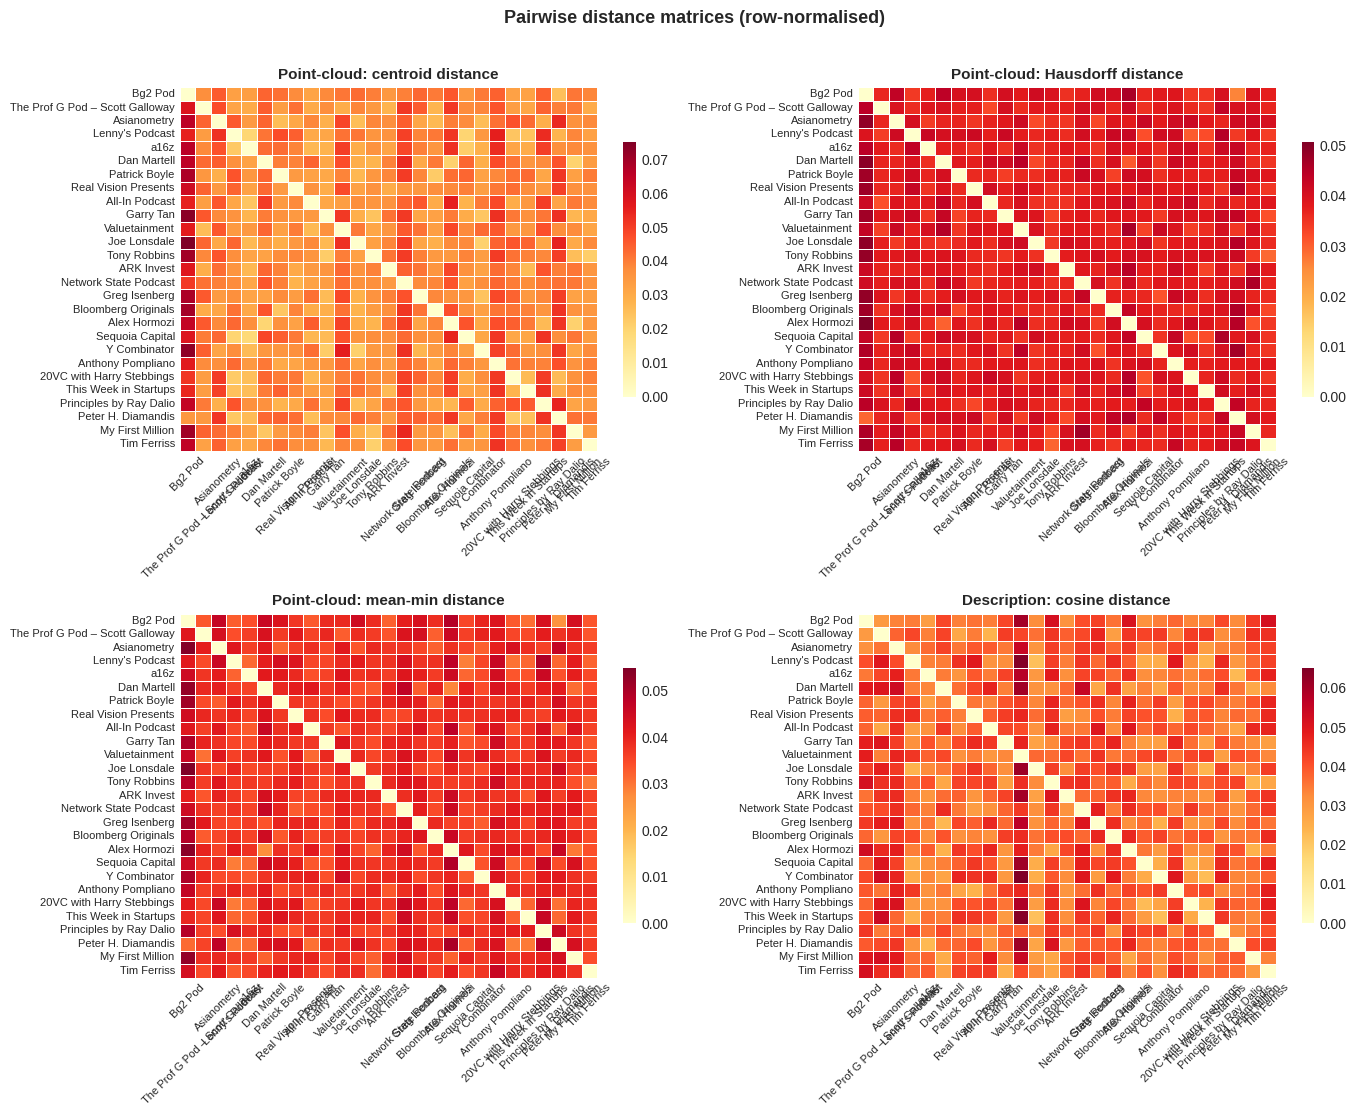

Saved → /content/drive/MyDrive/Research/distance_comparison/latest/distance_heatmaps.png


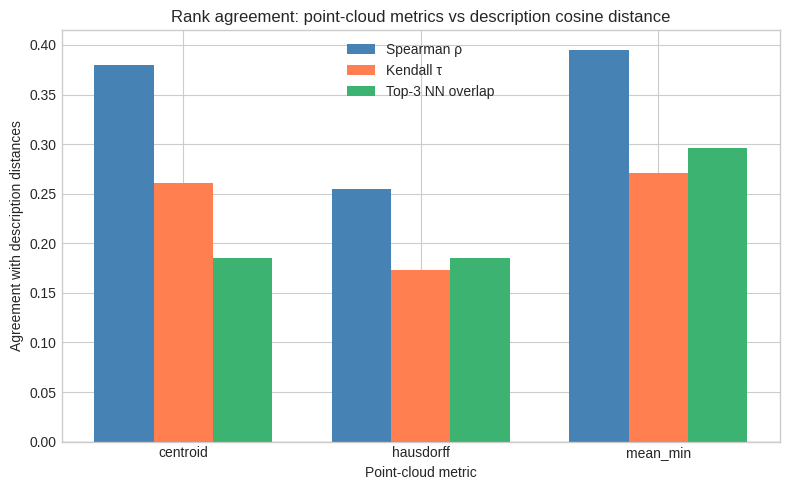

Saved → /content/drive/MyDrive/Research/distance_comparison/latest/rank_agreement_bars.png


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
heatmap_configs = [
    (centroid_norm,  'Point-cloud: centroid distance'),
    (hausdorff_norm, 'Point-cloud: Hausdorff distance'),
    (meanmin_norm,   'Point-cloud: mean-min distance'),
    (desc_cos_norm,  'Description: cosine distance'),
]

for ax, (mat, title) in zip(axes.flat, heatmap_configs):
    sns.heatmap(
        mat, ax=ax,
        xticklabels=channels, yticklabels=channels,
        cmap='YlOrRd', annot=(len(channels) <= 12),
        fmt='.2f', linewidths=.4, cbar_kws={'shrink': .7}
    )
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.suptitle('Pairwise distance matrices (row-normalised)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()

heatmap_path = RESEARCH_ROOT / 'distance_comparison' / 'latest' / 'distance_heatmaps.png'
heatmap_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(heatmap_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {heatmap_path}')

# ---- Bar chart: agreement metrics ----------------------------------------
fig2, ax2 = plt.subplots(figsize=(8, 5))
x      = np.arange(len(point_cloud_metrics))
width  = 0.25
labels = list(point_cloud_metrics.keys())

ax2.bar(x - width, agreement_df['spearman_rho'],  width, label='Spearman ρ',       color='steelblue')
ax2.bar(x,         agreement_df['kendall_tau'],    width, label='Kendall τ',        color='coral')
ax2.bar(x + width, agreement_df['top3_nn_overlap'],width, label='Top-3 NN overlap', color='mediumseagreen')

ax2.set_xlabel('Point-cloud metric')
ax2.set_ylabel('Agreement with description distances')
ax2.set_title('Rank agreement: point-cloud metrics vs description cosine distance')
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.axhline(0, color='k', linewidth=0.8)
ax2.legend()
plt.tight_layout()

bar_path = heatmap_path.parent / 'rank_agreement_bars.png'
plt.savefig(bar_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {bar_path}')


## 7) Save artifacts

Write the agreement table and the raw distance matrices to Drive so downstream analyses
can consume them without recomputing.


In [16]:
out_dir = RESEARCH_ROOT / 'distance_comparison' / 'latest'
out_dir.mkdir(parents=True, exist_ok=True)

# CSV agreement table
agreement_df.to_csv(out_dir / 'rank_agreement.csv')
print(f'Saved rank_agreement.csv → {out_dir}')

# Raw distance matrices as JSON
matrices_artifact = {
    'schema_version': '1.0.0',
    'channels': channels,
    'point_cloud_metrics': {
        name: mat.tolist() for name, mat in point_cloud_metrics.items()
    },
    'description_cosine': desc_cos_norm.tolist(),
    'rank_agreement':     agreement_df.reset_index().to_dict(orient='records'),
}

with open(out_dir / 'distance_matrices.json', 'w') as fh:
    json.dump(matrices_artifact, fh, indent=2)

print(f'Saved distance_matrices.json → {out_dir}')


Saved rank_agreement.csv → /content/drive/MyDrive/Research/distance_comparison/latest
Saved distance_matrices.json → /content/drive/MyDrive/Research/distance_comparison/latest
